<a href="https://colab.research.google.com/github/7amzaGH/TUBLEX-Bubble-Plume-Analysis/blob/main/notebooks/TUBLEX_RF_Video_Demo_Pipeline_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUBLEX RF Video Demo Pipeline Inference

**Repository:** [TUBLEX-Bubble-Plume-Analysis](https://github.com/7amzaGH/TUBLEX-Bubble-Plume-Analysis)

This notebook demonstrates the complete TUBLEX inference workflow on a user-provided video segment:

1. clone the GitHub repository,
2. load the selected Random Forest model,
3. visualize bubble detections using one frame per second,
4. extract 1-second temporal TUBLEX descriptors,
5. predict leak probability for each window,
6. save clean CSV tables and figures under `results/video_demo/`.

This notebook is intended as a friendly inference demo, not as the training or benchmarking notebook.

In [1]:
# ============================================================
# CLONE TUBLEX REPOSITORY
# ============================================================

from pathlib import Path
import os
import subprocess

REPO_URL = "https://github.com/7amzaGH/TUBLEX-Bubble-Plume-Analysis.git"
REPO_NAME = "TUBLEX-Bubble-Plume-Analysis"

current_dir = Path.cwd()

if (current_dir / "src" / "tublex").exists():
    PROJECT_ROOT = current_dir
else:
    repo_dir = current_dir / REPO_NAME

    if not repo_dir.exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)

    PROJECT_ROOT = repo_dir

os.chdir(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)
print("Repository ready:", (PROJECT_ROOT / "src" / "tublex").exists())

Project root: /content/TUBLEX-Bubble-Plume-Analysis
Repository ready: True


In [2]:
# ============================================================
# INSTALL REQUIREMENTS
# ============================================================

import sys
import subprocess
from pathlib import Path

REQUIREMENTS_PATH = PROJECT_ROOT / "requirements.txt"

if REQUIREMENTS_PATH.exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(REQUIREMENTS_PATH)],
        check=True,
    )
else:
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            "opencv-python", "scikit-learn", "pandas", "numpy",
            "joblib", "matplotlib", "tqdm"
        ],
        check=True,
    )

print("Dependencies installed.")

Dependencies installed.


In [3]:
# ============================================================
# IMPORT LIBRARIES AND TUBLEX MODULES
# ============================================================

import sys
from pathlib import Path

SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tublex.config import get_config, CONTROLLED_PLUME_ROI, FEATURE_COLUMNS
from tublex.preprocessing import preprocess_frame
from tublex.detection import detect_frame_bubbles
from tublex.video import process_video
from tublex.classifier import load_metadata, load_and_predict

print("TUBLEX modules loaded successfully.")
print("Number of model features:", len(FEATURE_COLUMNS))

TUBLEX modules loaded successfully.
Number of model features: 11


In [4]:
# ============================================================
# DEFINE MODEL, VIDEO, AND OUTPUT PATHS
# ============================================================

def first_existing_path(candidates):
    for path in candidates:
        path = Path(path)
        if path.exists():
            return path
    return Path(candidates[0])

RF_MODEL_DIR = first_existing_path([
    PROJECT_ROOT / "models" / "random_forest",
    PROJECT_ROOT / "models" / "Random_Forest_tublex",
])

MODEL_PATH = RF_MODEL_DIR / "rf_tublex_final.joblib"
METADATA_PATH = RF_MODEL_DIR / "rf_tublex_metadata.json"

RESULTS_DIR = PROJECT_ROOT / "results" / "video_demo"
TABLE_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FEATURES = TABLE_DIR / "video_demo_features.csv"
OUTPUT_PREDICTIONS = TABLE_DIR / "video_demo_predictions.csv"
OUTPUT_SUMMARY = TABLE_DIR / "video_demo_summary.csv"
OUTPUT_SNAPSHOT_SUMMARY = TABLE_DIR / "video_demo_detection_snapshot_summary.csv"

DETECTION_GRID_PATH = FIGURE_DIR / "video_demo_detection_grid.png"
PROBABILITY_PLOT_PATH = FIGURE_DIR / "video_demo_leak_probability.png"
CLASS_TIMELINE_PATH = FIGURE_DIR / "video_demo_predicted_class_timeline.png"
SHAP_FEATURE_PLOT_PATH = FIGURE_DIR / "video_demo_top_shap_features.png"

print("Model path:", MODEL_PATH)
print("Metadata path:", METADATA_PATH)
print("Table output directory:", TABLE_DIR)
print("Figure output directory:", FIGURE_DIR)

Model path: /content/TUBLEX-Bubble-Plume-Analysis/models/random_forest/rf_tublex_final.joblib
Metadata path: /content/TUBLEX-Bubble-Plume-Analysis/models/random_forest/rf_tublex_metadata.json
Table output directory: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/tables
Figure output directory: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/figures


In [6]:
# ============================================================
# DEFINE VIDEO DEMO SETTINGS
# ============================================================

# Upload your video to this path in Colab, or replace it with your own path.
VIDEO_PATH = Path("/content/G22-30 psi.MOV")

# Select the segment to analyze.
START_SEC = 15
END_SEC = 30

# TUBLEX visual profile.
# "standard" is the default publication-ready profile.
# "sparse" is more permissive for weak or few-bubble videos.
PROFILE = "standard"

# Keep ROI disabled for a general user demo.
# Enable only for controlled fixed-camera experiments.
USE_ROI = False

# Snapshot visualization setting.
# 0.0 = first frame of each second.
# 0.5 = middle frame of each second.
SNAPSHOT_OFFSET_SEC = 0.0

print("Video path:", VIDEO_PATH)
print("Segment:", START_SEC, "to", END_SEC, "seconds")
print("Profile:", PROFILE)
print("Use ROI:", USE_ROI)
print("Snapshot offset inside each second:", SNAPSHOT_OFFSET_SEC)

Video path: /content/G22-30 psi.MOV
Segment: 15 to 30 seconds
Profile: standard
Use ROI: False
Snapshot offset inside each second: 0.0


In [7]:
# ============================================================
# VALIDATE INPUT FILES
# ============================================================

missing_files = []

for path in [MODEL_PATH, METADATA_PATH]:
    if not Path(path).exists():
        missing_files.append(str(path))

if not VIDEO_PATH.exists():
    missing_files.append(str(VIDEO_PATH))

if missing_files:
    raise FileNotFoundError(
        "The following required files were not found:\n"
        + "\n".join(missing_files)
        + "\n\nUpload a video to VIDEO_PATH or edit the paths above."
    )

print("All required files found.")

All required files found.


In [8]:
# ============================================================
# LOAD CONFIGURATION AND MODEL METADATA
# ============================================================

roi = CONTROLLED_PLUME_ROI if USE_ROI else None
cfg = get_config(profile=PROFILE, roi=roi)

metadata = load_metadata(METADATA_PATH)

print("Configuration loaded.")
print("ROI:", cfg["roi"])
print("Output FPS:", cfg["output_fps"])
print("Window duration:", cfg["window_sec"], "second")

print("\nRandom Forest metadata:")
print("Model name:", metadata["model_name"])
print("Model type:", metadata["model_type"])
print("Decision threshold:", metadata["decision_threshold"])
print("Positive class:", metadata["positive_class"])
print("Feature count:", len(metadata["feature_columns"]))

Configuration loaded.
ROI: {'enabled': False, 'x_min': 0.0, 'x_max': 1.0, 'y_min': 0.0, 'y_max': 1.0}
Output FPS: 10
Window duration: 1.0 second

Random Forest metadata:
Model name: TUBLEX Model
Model type: Unknown
Decision threshold: 0.5
Positive class: 1
Feature count: 11


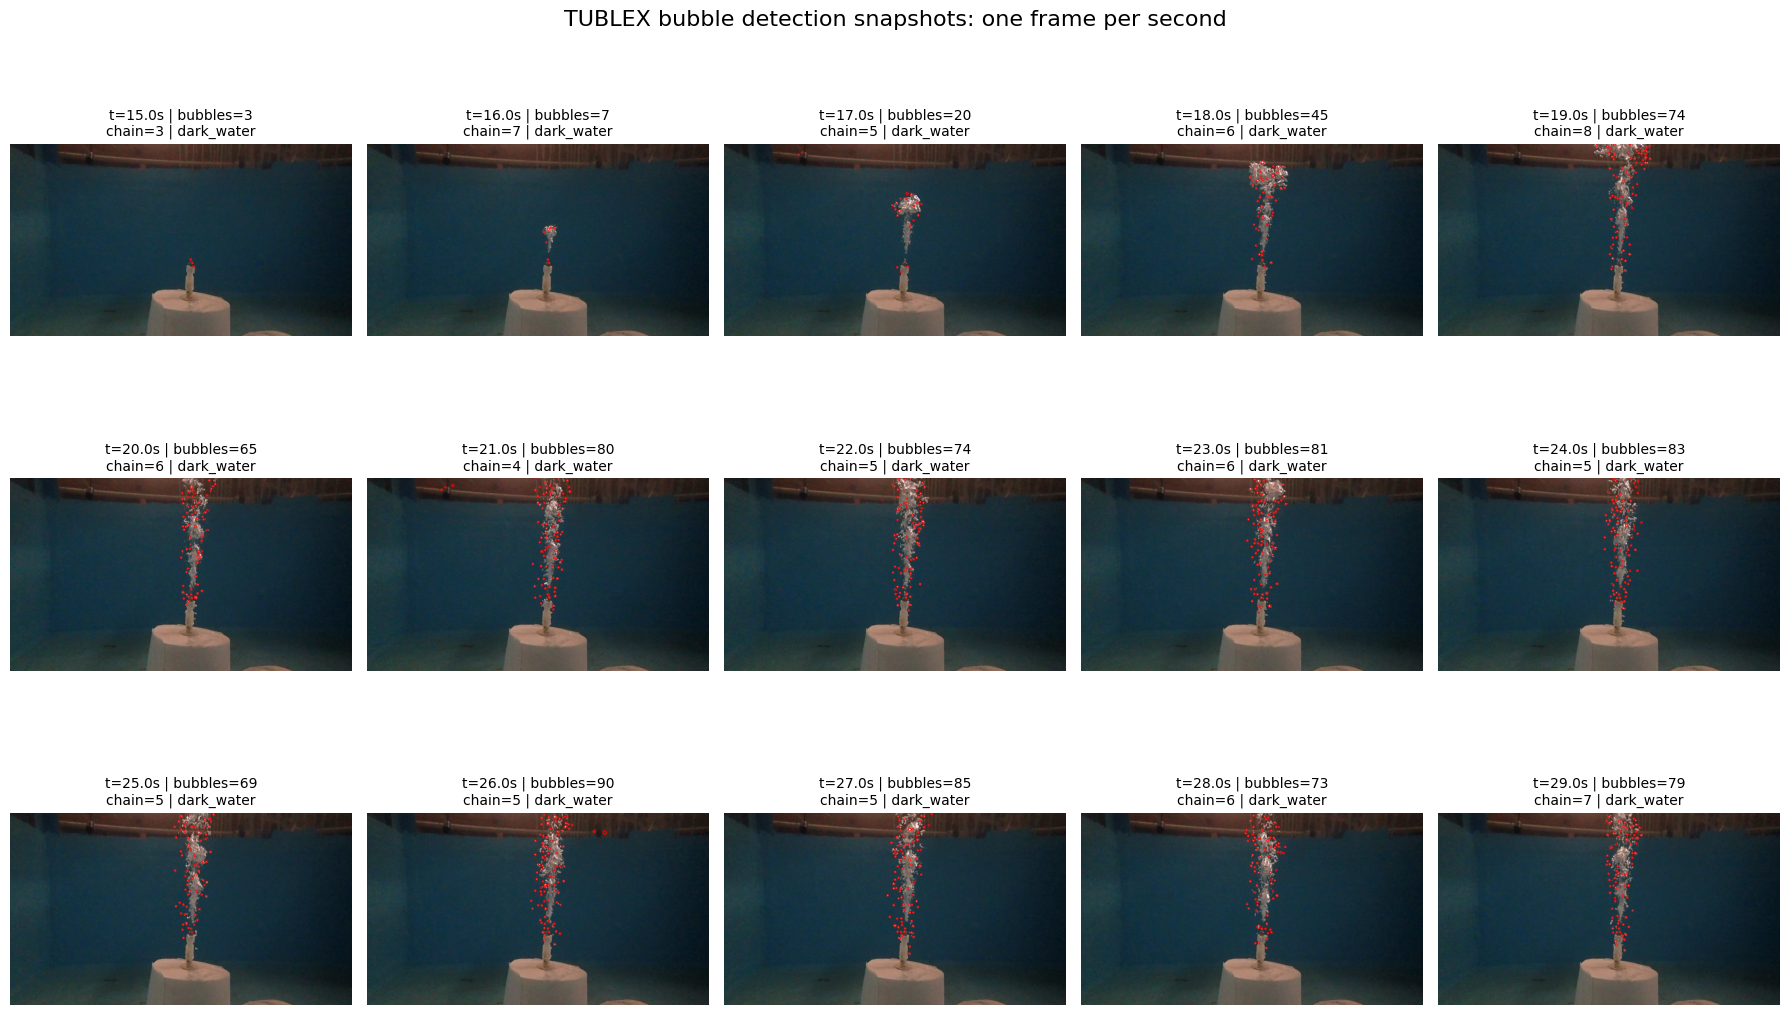

Saved detection grid: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/figures/video_demo_detection_grid.png
Saved snapshot summary: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/tables/video_demo_detection_snapshot_summary.csv


,time_sec,raw_candidates,filtered_bubbles,vertical_chain,water_type,water_v_mean,roi_enabled
0,15.0,4,3,3,dark_water,60.55,False
1,16.0,9,7,7,dark_water,60.67,False
2,17.0,21,20,5,dark_water,61.54,False
3,18.0,50,45,6,dark_water,62.21,False
4,19.0,78,74,8,dark_water,62.39,False
5,20.0,68,65,6,dark_water,62.06,False
6,21.0,83,80,4,dark_water,62.11,False
7,22.0,77,74,5,dark_water,62.30,False
8,23.0,84,81,6,dark_water,62.24,False
9,24.0,85,83,5,dark_water,62.04,False


In [9]:
# ============================================================
# VISUALIZE BUBBLE DETECTION SNAPSHOTS
# ============================================================

seconds_to_show = list(range(int(START_SEC), int(END_SEC)))

if len(seconds_to_show) == 0:
    raise ValueError("No seconds selected. Make sure END_SEC > START_SEC.")

cap = cv2.VideoCapture(str(VIDEO_PATH))

records = []
images = []

for sec in seconds_to_show:
    snapshot_time = sec + SNAPSHOT_OFFSET_SEC
    cap.set(cv2.CAP_PROP_POS_MSEC, snapshot_time * 1000)

    ret, frame = cap.read()

    if not ret:
        print(f"Warning: could not read frame at t={snapshot_time:.2f}s")
        continue

    prep = preprocess_frame(frame, cfg)
    det = detect_frame_bubbles(prep, cfg)

    frame_vis = frame.copy()

    if cfg["roi"]["enabled"]:
        x1, y1, x2, y2 = prep["roi_box"]
        cv2.rectangle(frame_vis, (x1, y1), (x2, y2), (255, 0, 0), 2)

    for p in det["points"]:
        center = (int(p["x"]), int(p["y"]))
        radius = max(3, int(p["size"] / 2))
        cv2.circle(frame_vis, center, radius, (0, 0, 255), 2)

    frame_rgb = cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB)

    images.append((snapshot_time, frame_rgb, det, prep))

    records.append({
        "time_sec": snapshot_time,
        "raw_candidates": det["raw_count"],
        "filtered_bubbles": det["bubble_count"],
        "vertical_chain": det["vertical_chain"],
        "water_type": prep["water_type"],
        "water_v_mean": round(prep["water_v_mean"], 2),
        "roi_enabled": cfg["roi"]["enabled"],
    })

cap.release()

if len(images) == 0:
    raise RuntimeError("No frames were read from the selected video segment.")

n_images = len(images)
n_cols = min(5, n_images)
n_rows = math.ceil(n_images / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.8 * n_rows))

if n_images == 1:
    axes = [axes]
else:
    axes = np.array(axes).reshape(-1)

for ax, (time_sec, img, det, prep) in zip(axes, images):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"t={time_sec:.1f}s | bubbles={det['bubble_count']}\n"
        f"chain={det['vertical_chain']} | {prep['water_type']}",
        fontsize=10,
    )

for ax in axes[len(images):]:
    ax.axis("off")

plt.suptitle("TUBLEX bubble detection snapshots: one frame per second", fontsize=16)
plt.tight_layout()
plt.savefig(DETECTION_GRID_PATH, dpi=200, bbox_inches="tight")
plt.show()

df_snapshot_summary = pd.DataFrame(records)
df_snapshot_summary.to_csv(OUTPUT_SNAPSHOT_SUMMARY, index=False)

print("Saved detection grid:", DETECTION_GRID_PATH)
print("Saved snapshot summary:", OUTPUT_SNAPSHOT_SUMMARY)

df_snapshot_summary

In [10]:
# ============================================================
# EXTRACT ONE-SECOND TUBLEX WINDOW FEATURES
# ============================================================

df_features = process_video(
    video_path=VIDEO_PATH,
    cfg=cfg,
    start_sec=START_SEC,
    end_sec=END_SEC,
    label_start=None,
    label_end=None,
    save_path=OUTPUT_FEATURES,
    debug=False,
)

if len(df_features) == 0:
    raise RuntimeError(
        "No 1-second feature windows were generated. "
        "Check the video path, segment duration, and video FPS."
    )

print("Feature extraction completed.")
print("Saved features:", OUTPUT_FEATURES)
print("Feature table shape:", df_features.shape)

df_features.head()

Feature extraction completed.
Saved features: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/tables/video_demo_features.csv
Feature table shape: (15, 17)


,sample_id,source_video_id,window_id,time_sec,g,psi,mean_bubble_count,max_bubble_count,std_bubble_count,continuity_ratio,mean_vertical_chain,temporal_variance,prev3_mean_bubble_count,prev3_std_bubble_count,prev3_continuity_ratio,prev3_mean_vertical_chain,leak_evolution
0,G22-30 psi_w0000,G22-30 psi,0,16.0,22,30,2.5,5.0,1.269296,0.9,2.3,1.611111,0.000000,0.000000,0.000000,0.000000,2.500000
1,G22-30 psi_w0001,G22-30 psi,1,17.0,22,30,10.3,17.0,3.860052,1.0,5.2,14.900000,2.500000,1.269296,0.900000,2.300000,7.800000
2,G22-30 psi_w0002,G22-30 psi,2,18.0,22,30,27.7,39.0,8.287206,1.0,7.7,68.677778,6.400000,2.564674,0.950000,3.750000,21.300000
3,G22-30 psi_w0003,G22-30 psi,3,19.0,22,30,54.8,69.0,9.897250,1.0,5.3,97.955556,13.500000,4.472184,0.966667,5.066667,41.300000
4,G22-30 psi_w0004,G22-30 psi,4,20.0,22,30,64.2,69.0,3.823901,1.0,6.5,14.622222,30.933333,7.348169,1.000000,6.066667,33.266667


In [11]:
# ============================================================
# DISPLAY EXTRACTED WINDOW-LEVEL FEATURES
# ============================================================

feature_display_columns = [
    "sample_id",
    "source_video_id",
    "window_id",
    "time_sec",
    "mean_bubble_count",
    "max_bubble_count",
    "std_bubble_count",
    "continuity_ratio",
    "mean_vertical_chain",
    "temporal_variance",
    "leak_evolution",
]

available_columns = [c for c in feature_display_columns if c in df_features.columns]

df_features[available_columns].head(20)

,sample_id,source_video_id,window_id,time_sec,mean_bubble_count,max_bubble_count,std_bubble_count,continuity_ratio,mean_vertical_chain,temporal_variance,leak_evolution
0,G22-30 psi_w0000,G22-30 psi,0,16.0,2.5,5.0,1.269296,0.9,2.3,1.611111,2.500000
1,G22-30 psi_w0001,G22-30 psi,1,17.0,10.3,17.0,3.860052,1.0,5.2,14.900000,7.800000
2,G22-30 psi_w0002,G22-30 psi,2,18.0,27.7,39.0,8.287206,1.0,7.7,68.677778,21.300000
3,G22-30 psi_w0003,G22-30 psi,3,19.0,54.8,69.0,9.897250,1.0,5.3,97.955556,41.300000
4,G22-30 psi_w0004,G22-30 psi,4,20.0,64.2,69.0,3.823901,1.0,6.5,14.622222,33.266667
5,G22-30 psi_w0005,G22-30 psi,5,21.0,68.8,79.0,7.036413,1.0,5.5,49.511111,19.900000
6,G22-30 psi_w0006,G22-30 psi,6,22.0,73.1,77.0,3.247221,1.0,5.4,10.544444,10.500000
7,G22-30 psi_w0007,G22-30 psi,7,23.0,73.2,83.0,5.750362,1.0,6.3,33.066667,4.500000
8,G22-30 psi_w0008,G22-30 psi,8,24.0,71.8,79.0,4.939636,1.0,4.7,24.400000,0.100000
9,G22-30 psi_w0009,G22-30 psi,9,25.0,78.0,88.0,6.683313,1.0,5.1,44.666667,5.300000


In [12]:
# ============================================================
# SUMMARIZE THE ELEVEN MODEL FEATURES
# ============================================================

feature_summary = df_features[FEATURE_COLUMNS].describe().T
feature_summary = feature_summary[["mean", "std", "min", "max"]]

feature_summary

,mean,std,min,max
mean_bubble_count,59.906667,25.163365,2.500000,78.000000
max_bubble_count,68.800000,26.665119,5.000000,91.000000
std_bubble_count,5.693507,2.457959,1.269296,9.897250
continuity_ratio,0.993333,0.025820,0.900000,1.000000
mean_vertical_chain,5.533333,1.160460,2.300000,7.700000
temporal_variance,38.054815,29.026996,1.611111,97.955556
prev3_mean_bubble_count,50.060000,30.324958,0.000000,75.600000
prev3_std_bubble_count,4.903343,2.177914,0.000000,7.348169
prev3_continuity_ratio,0.921111,0.256384,0.000000,1.000000
prev3_mean_vertical_chain,4.936667,1.711889,0.000000,6.500000


In [13]:
# ============================================================
# RUN RANDOM FOREST INFERENCE
# ============================================================

df_pred = load_and_predict(
    df=df_features,
    model_path=MODEL_PATH,
    metadata_path=METADATA_PATH,
)

df_pred.to_csv(OUTPUT_PREDICTIONS, index=False)

print("Prediction completed.")
print("Saved predictions:", OUTPUT_PREDICTIONS)
print("Prediction table shape:", df_pred.shape)

df_pred.head()

Prediction completed.
Saved predictions: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/tables/video_demo_predictions.csv
Prediction table shape: (15, 20)


,sample_id,source_video_id,window_id,time_sec,g,psi,mean_bubble_count,max_bubble_count,std_bubble_count,continuity_ratio,mean_vertical_chain,temporal_variance,prev3_mean_bubble_count,prev3_std_bubble_count,prev3_continuity_ratio,prev3_mean_vertical_chain,leak_evolution,leak_probability,predicted_label,predicted_class
0,G22-30 psi_w0000,G22-30 psi,0,16.0,22,30,2.5,5.0,1.269296,0.9,2.3,1.611111,0.000000,0.000000,0.000000,0.000000,2.500000,0.00,0,non_leak
1,G22-30 psi_w0001,G22-30 psi,1,17.0,22,30,10.3,17.0,3.860052,1.0,5.2,14.900000,2.500000,1.269296,0.900000,2.300000,7.800000,0.97,1,leak
2,G22-30 psi_w0002,G22-30 psi,2,18.0,22,30,27.7,39.0,8.287206,1.0,7.7,68.677778,6.400000,2.564674,0.950000,3.750000,21.300000,1.00,1,leak
3,G22-30 psi_w0003,G22-30 psi,3,19.0,22,30,54.8,69.0,9.897250,1.0,5.3,97.955556,13.500000,4.472184,0.966667,5.066667,41.300000,1.00,1,leak
4,G22-30 psi_w0004,G22-30 psi,4,20.0,22,30,64.2,69.0,3.823901,1.0,6.5,14.622222,30.933333,7.348169,1.000000,6.066667,33.266667,1.00,1,leak


In [14]:
# ============================================================
# RANDOM FOREST PREDICTIONS
# ============================================================

prediction_columns = [
    "sample_id",
    "window_id",
    "time_sec",
    "mean_bubble_count",
    "std_bubble_count",
    "temporal_variance",
    "mean_vertical_chain",
    "leak_evolution",
    "leak_probability",
    "predicted_label",
    "predicted_class",
]

available_prediction_columns = [c for c in prediction_columns if c in df_pred.columns]

df_pred[available_prediction_columns].head(30)

,sample_id,window_id,time_sec,mean_bubble_count,std_bubble_count,temporal_variance,mean_vertical_chain,leak_evolution,leak_probability,predicted_label,predicted_class
0,G22-30 psi_w0000,0,16.0,2.5,1.269296,1.611111,2.3,2.500000,0.00,0,non_leak
1,G22-30 psi_w0001,1,17.0,10.3,3.860052,14.900000,5.2,7.800000,0.97,1,leak
2,G22-30 psi_w0002,2,18.0,27.7,8.287206,68.677778,7.7,21.300000,1.00,1,leak
3,G22-30 psi_w0003,3,19.0,54.8,9.897250,97.955556,5.3,41.300000,1.00,1,leak
4,G22-30 psi_w0004,4,20.0,64.2,3.823901,14.622222,6.5,33.266667,1.00,1,leak
5,G22-30 psi_w0005,5,21.0,68.8,7.036413,49.511111,5.5,19.900000,1.00,1,leak
6,G22-30 psi_w0006,6,22.0,73.1,3.247221,10.544444,5.4,10.500000,1.00,1,leak
7,G22-30 psi_w0007,7,23.0,73.2,5.750362,33.066667,6.3,4.500000,1.00,1,leak
8,G22-30 psi_w0008,8,24.0,71.8,4.939636,24.400000,4.7,0.100000,1.00,1,leak
9,G22-30 psi_w0009,9,25.0,78.0,6.683313,44.666667,5.1,5.300000,1.00,1,leak


In [15]:
# ============================================================
# VIDEO-LEVEL SUMMARY TABLE
# ============================================================

summary = {
    "video_path": str(VIDEO_PATH),
    "profile": PROFILE,
    "roi_enabled": cfg["roi"]["enabled"],
    "start_sec": START_SEC,
    "end_sec": END_SEC,
    "n_windows": len(df_pred),
    "mean_leak_probability": float(df_pred["leak_probability"].mean()),
    "max_leak_probability": float(df_pred["leak_probability"].max()),
    "min_leak_probability": float(df_pred["leak_probability"].min()),
    "predicted_leak_windows": int((df_pred["predicted_label"] == 1).sum()),
    "predicted_non_leak_windows": int((df_pred["predicted_label"] == 0).sum()),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUTPUT_SUMMARY, index=False)

print("Saved summary:", OUTPUT_SUMMARY)

summary_df

Saved summary: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/tables/video_demo_summary.csv


,video_path,profile,roi_enabled,start_sec,end_sec,n_windows,mean_leak_probability,max_leak_probability,min_leak_probability,predicted_leak_windows,predicted_non_leak_windows
0,/content/G22-30 psi.MOV,standard,False,15,30,15,0.931333,1.0,0.0,14,1


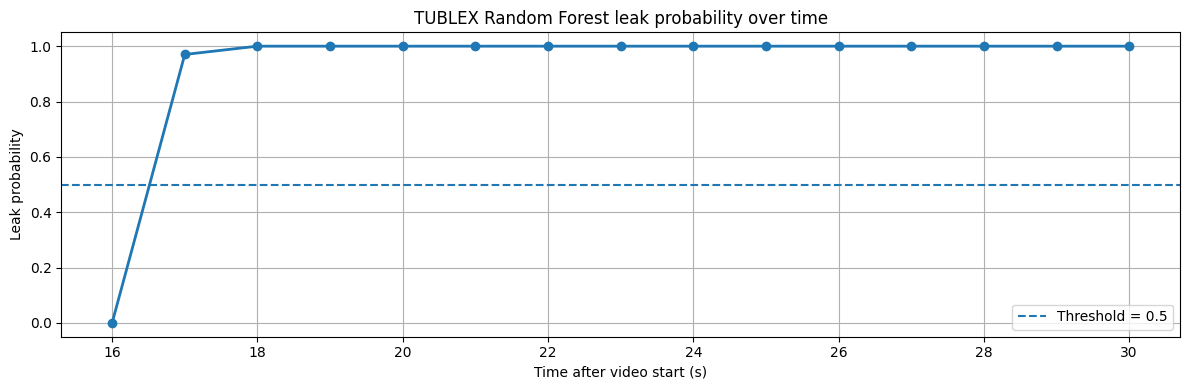

Saved probability plot: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/figures/video_demo_leak_probability.png


In [16]:
# ============================================================
# PLOT LEAK PROBABILITY OVER TIME
# ============================================================

plt.figure(figsize=(12, 4))

plt.plot(
    df_pred["time_sec"],
    df_pred["leak_probability"],
    marker="o",
    linewidth=2,
)

plt.axhline(
    metadata["decision_threshold"],
    linestyle="--",
    label=f"Threshold = {metadata['decision_threshold']}",
)

plt.xlabel("Time after video start (s)")
plt.ylabel("Leak probability")
plt.title("TUBLEX Random Forest leak probability over time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(PROBABILITY_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("Saved probability plot:", PROBABILITY_PLOT_PATH)

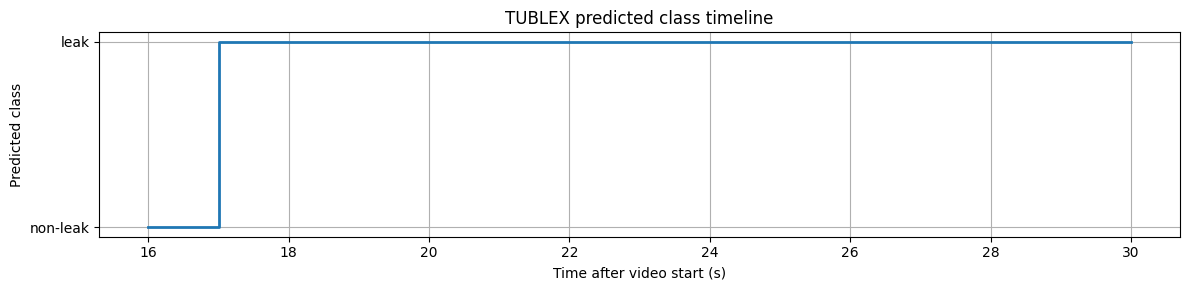

Saved class timeline: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/figures/video_demo_predicted_class_timeline.png


In [17]:
# ============================================================
# PLOT PREDICTED CLASS TIMELINE
# ============================================================

plt.figure(figsize=(12, 3))

plt.step(
    df_pred["time_sec"],
    df_pred["predicted_label"],
    where="post",
    linewidth=2,
)

plt.yticks([0, 1], ["non-leak", "leak"])
plt.xlabel("Time after video start (s)")
plt.ylabel("Predicted class")
plt.title("TUBLEX predicted class timeline")
plt.grid(True)
plt.tight_layout()
plt.savefig(CLASS_TIMELINE_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("Saved class timeline:", CLASS_TIMELINE_PATH)

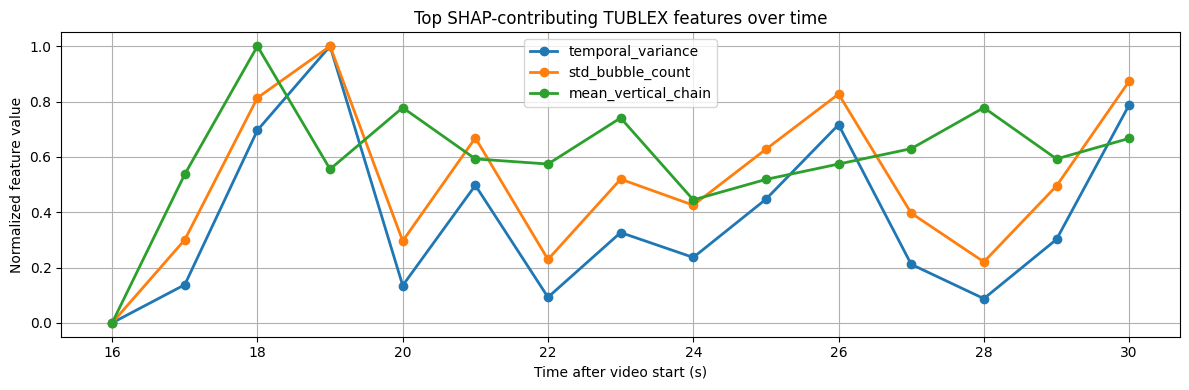

Saved top-feature plot: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/figures/video_demo_top_shap_features.png


In [18]:
# ============================================================
# PLOT TOP SHAP-CONTRIBUTING FEATURES OVER TIME
# ============================================================

top_features = [
    "temporal_variance",
    "std_bubble_count",
    "mean_vertical_chain",
]

plot_df = df_pred[["time_sec"] + top_features].copy()

for col in top_features:
    col_min = plot_df[col].min()
    col_max = plot_df[col].max()

    if col_max > col_min:
        plot_df[col] = (plot_df[col] - col_min) / (col_max - col_min)
    else:
        plot_df[col] = 0.0

plt.figure(figsize=(12, 4))

for col in top_features:
    plt.plot(
        plot_df["time_sec"],
        plot_df[col],
        marker="o",
        linewidth=2,
        label=col,
    )

plt.xlabel("Time after video start (s)")
plt.ylabel("Normalized feature value")
plt.title("Top SHAP-contributing TUBLEX features over time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(SHAP_FEATURE_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("Saved top-feature plot:", SHAP_FEATURE_PLOT_PATH)

In [19]:
# ============================================================
# FINAL VIDEO-LEVEL RESULT STATEMENT
# ============================================================

dominant_class = df_pred["predicted_class"].mode().iloc[0]
max_prob = df_pred["leak_probability"].max()
mean_prob = df_pred["leak_probability"].mean()

print("Final TUBLEX video-level summary")
print("--------------------------------")
print(f"Dominant predicted class: {dominant_class}")
print(f"Maximum leak probability: {max_prob:.4f}")
print(f"Mean leak probability: {mean_prob:.4f}")
print(f"Number of analyzed 1-second windows: {len(df_pred)}")
print(f"Saved feature CSV: {OUTPUT_FEATURES}")
print(f"Saved prediction CSV: {OUTPUT_PREDICTIONS}")
print(f"Saved summary CSV: {OUTPUT_SUMMARY}")

Final TUBLEX video-level summary
--------------------------------
Dominant predicted class: leak
Maximum leak probability: 1.0000
Mean leak probability: 0.9313
Number of analyzed 1-second windows: 15
Saved feature CSV: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/tables/video_demo_features.csv
Saved prediction CSV: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/tables/video_demo_predictions.csv
Saved summary CSV: /content/TUBLEX-Bubble-Plume-Analysis/results/video_demo/tables/video_demo_summary.csv
